In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sem_apme_2025-track_coordinates (6).csv", sep="\t")

df.columns = [c.strip() for c in df.columns]
rename_map = {
    "altitude (m)": "altitude_m",
    "altitude": "altitude_m",
    "distance (km)": "distance_km",
    "distance(km)": "distance_km",
}
df = df.rename(columns=rename_map)


required = ["latitude", "longitude", "altitude_m", "distance_km"]
missing = [c for c in required if c not in df.columns]
print("Missing:", missing)


df["distance_m"] = df["distance_km"].astype(float) * 1000.0


df["track_pos_norm"] = df["distance_m"] / df["distance_m"].iloc[-1]

df.head()


Missing: []


,Id,latitude,longitude,altitude_m,distance_km,distance_m,track_pos_norm
0,0,25.488420,51.450170,11.7,0.000,0.0,0.000000
1,1,25.488428,51.450166,11.7,0.001,1.0,0.000272
2,2,25.488436,51.450161,11.7,0.002,2.0,0.000544
3,3,25.488444,51.450156,11.7,0.003,3.0,0.000816
4,4,25.488452,51.450151,11.7,0.004,4.0,0.001088


In [ ]:

dh = df["altitude_m"].diff().fillna(0.0)
ds = df["distance_m"].diff().replace(0, np.nan).fillna(method="bfill")

df["slope"] = (dh / ds).fillna(0.0)
df["slope_pct"] = df["slope"] * 100.0

df[["distance_m","altitude_m","slope","slope_pct"]].head(10)


/tmp/ipython-input-1361990070.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ds = df["distance_m"].diff().replace(0, np.nan).fillna(method="bfill")


,distance_m,altitude_m,slope,slope_pct
0,0.0,11.7,0.0,0.0
1,1.0,11.7,0.0,0.0
2,2.0,11.7,0.0,0.0
3,3.0,11.7,0.0,0.0
4,4.0,11.7,0.0,0.0
5,5.0,11.7,0.0,0.0
6,6.0,11.7,0.0,0.0
7,7.0,11.8,0.1,10.0
8,8.0,11.8,0.0,0.0
9,9.0,11.8,0.0,0.0


In [ ]:
# الداتا الأصلية (Raw Track Data)
# latitude
# longitude
# altitude
# distance

# لداتا اللي “اتولّدت” من التراك (Feature Engineering)
# distance_m
# track_pos_norm
# slope
# slope_pct
# x_m , y_m
# curvature
# curvature_smooth
# radius_m
# v_limit_kmh

# الداتا اللي اتولّدت من السيميوليشن
# v_kmh
# t_s
# P_batt_W
# motor_on
# E_Wh_cum





In [ ]:
R = 6371000.0
lat = np.radians(df["latitude"].astype(float).values)
lon = np.radians(df["longitude"].astype(float).values)

lat0, lon0 = lat[0], lon[0]
df["x_m"] = R * (lon - lon0) * np.cos(lat0)
df["y_m"] = R * (lat - lat0)

df[["x_m","y_m"]].head()


,x_m,y_m
0,0.000000,0.000000
1,-0.432606,0.904015
2,-0.895323,1.793574
3,-1.382130,2.669790
4,-1.893027,3.531551


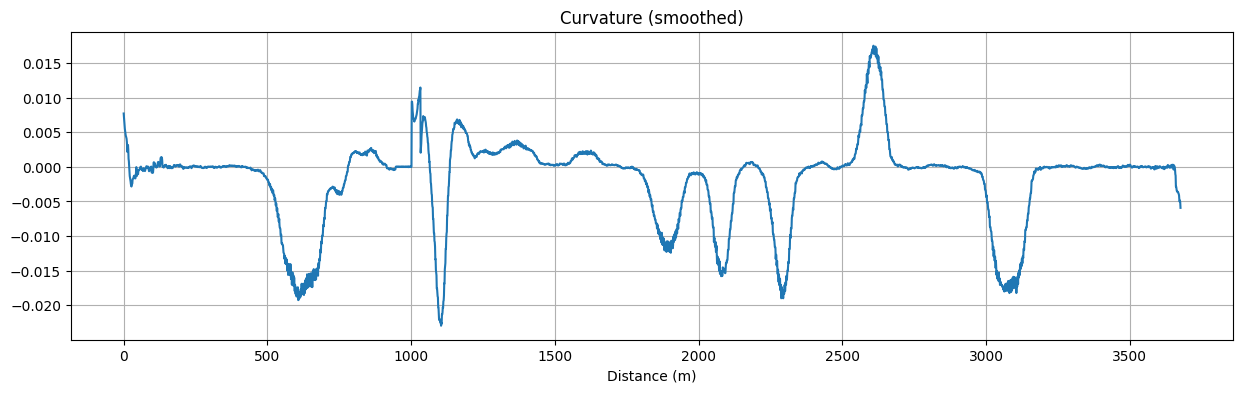

In [ ]:
def compute_curvature_xy(x, y):
    k = np.zeros(len(x), dtype=float)
    for i in range(1, len(x)-1):
        x1,y1 = x[i-1], y[i-1]
        x2,y2 = x[i],   y[i]
        x3,y3 = x[i+1], y[i+1]

        v1 = np.array([x2-x1, y2-y1], dtype=float)
        v2 = np.array([x3-x2, y3-y2], dtype=float)

        cross = v1[0]*v2[1] - v1[1]*v2[0]
        dot   = v1[0]*v2[0] + v1[1]*v2[1]
        ang = np.arctan2(cross, dot)

        ds = np.linalg.norm(v2)
        k[i] = ang / ds if ds > 1e-9 else 0.0
    return k

df["curvature"] = compute_curvature_xy(df["x_m"].values, df["y_m"].values)

df["curvature_smooth"] = (
    df["curvature"]
    .rolling(window=31, center=True, min_periods=1)
    .mean()
)

# radius (m)
eps = 1e-9
df["radius_m"] = 1.0 / (np.abs(df["curvature_smooth"]) + eps)

# Plot curvature
plt.figure(figsize=(15,4))
plt.plot(df["distance_m"], df["curvature_smooth"])
plt.title("Curvature (smoothed)")
plt.xlabel("Distance (m)")
plt.grid(True)
plt.show()


In [ ]:
# ثوابت (من شيت العربية عندك عدّلهم لاحقًا)
m = 110.0          # kg (لو العربية+سائق)
Crr = 0.0025
Cd  = 0.22
A   = 0.5
rho = 1.2

eta_total = 0.95 * 0.75 * 0.95  # drivetrain*motor*controller

def resistive_force(v_ms, slope):
    F_roll  = Crr * m * g
    F_aero  = 0.5 * rho * Cd * A * v_ms**2
    F_grade = m * g * slope
    return F_roll + F_aero + F_grade

def pulse_glide_sim(df, v_low_kmh=20.0, v_high_kmh=30.0, P_on_wheel_W=250.0):
    """
    Motor_cmd = 1 لو v < v_low ، Motor_cmd = 0 لو v > v_high (hysteresis)
    Integration على المسافة ds باستخدام: v_next^2 = v^2 + 2*a*ds
    """
    s = df["distance_m"].values
    ds = np.diff(s)
    ds = np.append(ds, ds[-1])

    slope = df["slope"].values
    vlim = df["v_limit_kmh"].values / 3.6

    v = 0.0  # start from 0 m/s
    t_cum = 0.0
    E_Wh = 0.0

    motor_on = 1
    out_v = []
    out_t = []
    out_Pbatt = []
    out_motor = []
    out_Ecum = []

    v_low = v_low_kmh/3.6
    v_high = v_high_kmh/3.6

    for i in range(len(df)):
        # enforce corner limit (تبطيء بدون regen)
        if v > vlim[i]:
            v = vlim[i]

        # hysteresis ON/OFF
        if v <= v_low:
            motor_on = 1
        elif v >= v_high:
            motor_on = 0

        # forces
        Fres = resistive_force(v, slope[i])

        # drive force from power (لو motor ON)
        if motor_on == 1 and v > 0.5:
            Fdrive = P_on_wheel_W / v
        elif motor_on == 1 and v <= 0.5:
            # بداية الحركة: force cap بسيطة
            Fdrive = P_on_wheel_W / 0.5
        else:
            Fdrive = 0.0

        a = (Fdrive - Fres) / m  # m/s^2

        # update speed by distance step
        v2_next = max(0.0, v*v + 2*a*ds[i])
        v_next = np.sqrt(v2_next)
        v_next = min(v_next, 40.0 / 3.6)


        # time step (تقريب)
        v_avg = max(0.5, 0.5*(v + v_next))
        dt = ds[i] / v_avg
        t_cum += dt

        # battery power (ON only)
        P_wheel = Fdrive * v_avg
        P_batt = (P_wheel / eta_total) if motor_on == 1 else 0.0

        E_Wh += (P_batt * dt) / 3600.0

        # log
        v = v_next
        out_v.append(v*3.6)
        out_t.append(t_cum)
        out_Pbatt.append(P_batt)
        out_motor.append(motor_on)
        out_Ecum.append(E_Wh)

    sim = pd.DataFrame({
        "distance_m": df["distance_m"].values,
        "v_kmh": np.array(out_v),
        "t_s": np.array(out_t),
        "P_batt_W": np.array(out_Pbatt),
        "motor_on": np.array(out_motor),
        "E_Wh_cum": np.array(out_Ecum),
    })
    return sim


In [ ]:

g = 9.81
mu = 0.7
df["v_limit_ms"] = np.sqrt(mu * g * df["radius_m"])
df["v_limit_kmh"] = df["v_limit_ms"] * 3.6

df["v_limit_kmh"] = np.clip(df["v_limit_kmh"], 0, 40)

df[["distance_m", "v_limit_kmh"]].head()


,distance_m,v_limit_kmh
0,0.0,40.0
1,1.0,40.0
2,2.0,40.0
3,3.0,40.0
4,4.0,40.0


Lap time (min): 9.1366785648626
Lap energy (Wh): 10.449600428183096
Motor ON ratio: 0.22980690780527604


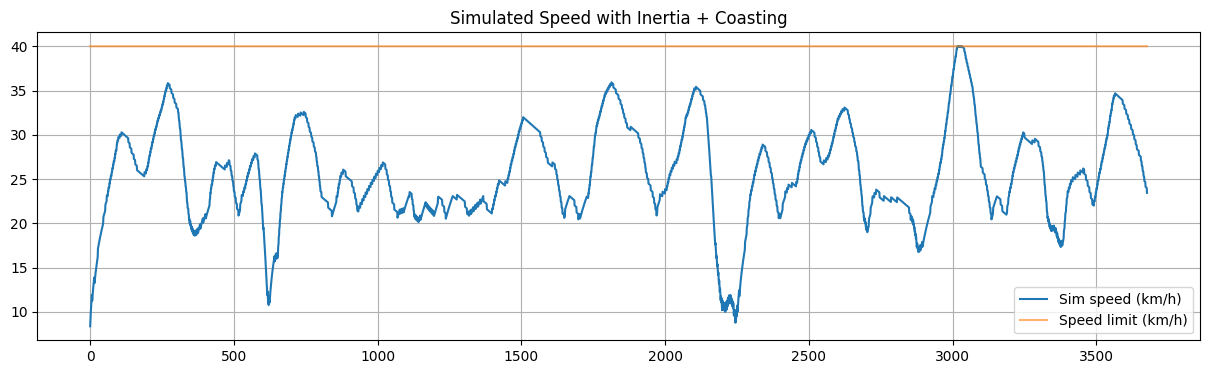

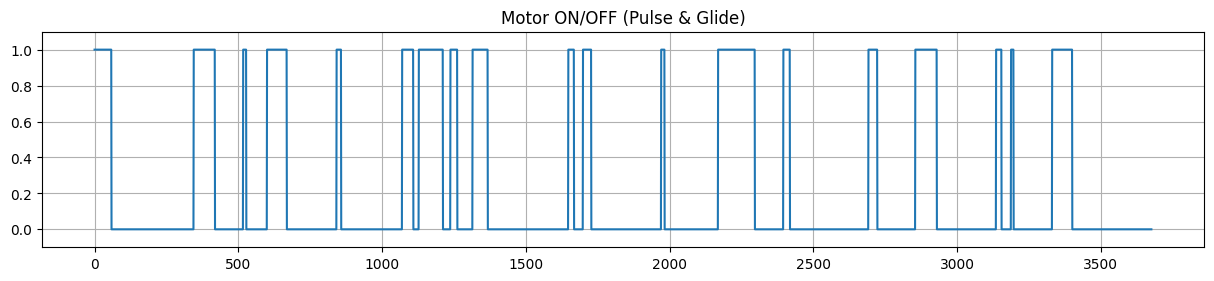

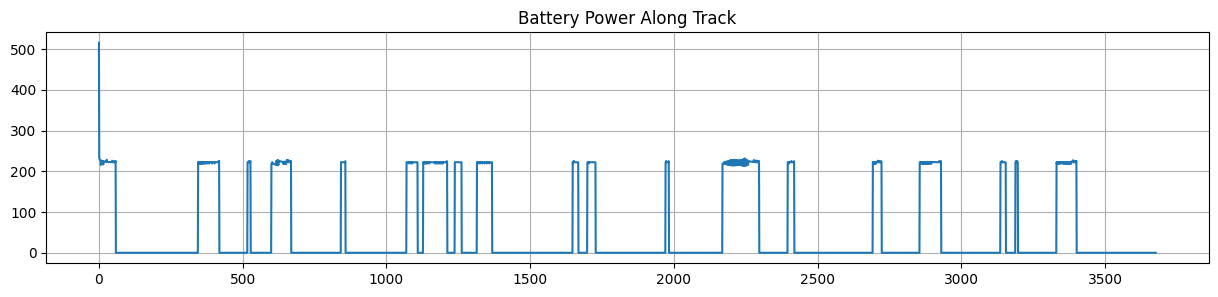

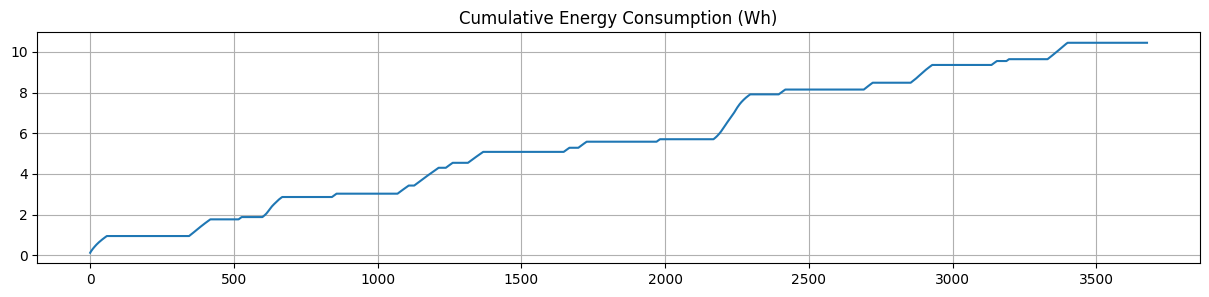

In [ ]:
sim = pulse_glide_sim(df, v_low_kmh=21, v_high_kmh=23, P_on_wheel_W=150)

print("Lap time (min):", sim["t_s"].iloc[-1]/60)
print("Lap energy (Wh):", sim["E_Wh_cum"].iloc[-1])
print("Motor ON ratio:", sim["motor_on"].mean())




# Speed vs limit
plt.figure(figsize=(15,4))
plt.plot(sim["distance_m"], sim["v_kmh"], label="Sim speed (km/h)")
plt.plot(df["distance_m"], df["v_limit_kmh"], alpha=0.6, label="Speed limit (km/h)")
plt.grid(True); plt.legend()
plt.title("Simulated Speed with Inertia + Coasting")
plt.show()

# Motor ON/OFF
plt.figure(figsize=(15,2.8))
plt.plot(sim["distance_m"], sim["motor_on"])
plt.ylim([-0.1,1.1])
plt.grid(True)
plt.title("Motor ON/OFF (Pulse & Glide)")
plt.show()

# Battery power
plt.figure(figsize=(15,3))
plt.plot(sim["distance_m"], sim["P_batt_W"])
plt.grid(True)
plt.title("Battery Power Along Track")
plt.show()

# Cumulative energy
plt.figure(figsize=(15,3))
plt.plot(sim["distance_m"], sim["E_Wh_cum"])
plt.grid(True)
plt.title("Cumulative Energy Consumption (Wh)")
plt.show()


In [ ]:
best = None
records = []

for v_low in np.arange(20, 30, 1):
    for v_high in np.arange(v_low+1, v_low+4, 1):
        for P_on in np.arange(60, 151, 10):

            sim_try = pulse_glide_sim(
                df,
                v_low_kmh=v_low,
                v_high_kmh=v_high,
                P_on_wheel_W=P_on
            )

            lap_time_min = sim_try["t_s"].iloc[-1] / 60
            lap_energy   = sim_try["E_Wh_cum"].iloc[-1]

            laps_needed = 14 / (df["distance_m"].iloc[-1] / 1000)
            race_time   = lap_time_min * laps_needed
            race_energy = lap_energy * laps_needed

            if race_time <= 35.0:
                records.append([v_low, v_high, P_on, race_time, race_energy])

                if best is None or race_energy < best[-1]:
                    best = [v_low, v_high, P_on, race_time, race_energy]

best


[np.int64(21),
 np.int64(23),
 np.int64(150),
 np.float64(34.79692598152241),
 np.float64(39.79717246859721)]

In [ ]:
best_v_low, best_v_high, best_P_on, best_race_time, best_race_energy = best


In [ ]:
print("Max speed reached:", sim["v_kmh"].max())
print("Race time (min):", (sim["t_s"].iloc[-1]/60) * laps_needed)
print("Race energy (Wh):", sim["E_Wh_cum"].iloc[-1] * laps_needed)

Max speed reached: 40.0
Race time (min): 34.79692598152241
Race energy (Wh): 39.79717246859721


In [ ]:
print("Best race energy (Wh):", best_race_energy)
print("Best race time (min):", best_race_time)
print("Best strategy (v_low, v_high, P_on):",
      best_v_low, best_v_high, best_P_on)


Best race energy (Wh): 39.79717246859721
Best race time (min): 34.79692598152241
Best strategy (v_low, v_high, P_on): 21 23 150


In [ ]:
battery_capacity_Wh = 525
battery_used_pct = (best_race_energy / battery_capacity_Wh) * 100

print("Battery used (%):", battery_used_pct)


Battery used (%): 7.580413803542325


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam


In [ ]:
features = [
    "slope",
    "curvature_smooth",
    "v_kmh",
    "motor_on",
    "v_limit_kmh"
]

target = "energy_step_Wh"


In [ ]:
df_ml = df.copy()

sim["energy_step_Wh"] = sim["E_Wh_cum"].diff().fillna(0)

df_ml["v_kmh"] = sim["v_kmh"].values
df_ml["motor_on"] = sim["motor_on"].values
df_ml["energy_step_Wh"] = sim["energy_step_Wh"].values

df_ml = df_ml.dropna().reset_index(drop=True)

In [ ]:
window = 20
n_features = len(features)


In [ ]:
def make_sequences(df, features, target, window):
    X, y = [], []
    for i in range(len(df) - window):
        X.append(df[features].iloc[i:i+window].values)
        y.append(df[target].iloc[i+window])
    return np.array(X), np.array(y)


In [ ]:
X, y = make_sequences(df_ml, features, target, window)

print(X.shape)  # (samples, window, features)
print(y.shape)


(3657, 20, 5)
(3657,)


In [ ]:
split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]


In [ ]:
model = Sequential([
    LSTM(64, input_shape=(window, n_features)),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0059 - val_loss: 1.6764e-05
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.1433e-05 - val_loss: 6.3313e-06
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0251e-05 - val_loss: 6.3585e-06
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.6698e-06 - val_loss: 4.9451e-06
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.7977e-06 - val_loss: 1.0771e-05
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.1107e-06 - val_loss: 5.1044e-06
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6155e-06 - val_loss: 5.8150e-06
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.0248e-06 - val_loss: 8.4637e-06
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.8734e-06 - val_loss: 7.3418e-06
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8592e-06 - val_loss: 5.4237e-06
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0543e-06 - val_loss: 

In [ ]:
y_pred_A = model.predict(X_val).flatten()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
mse_A = np.mean((y_val - y_pred_A)**2)
print("MSE_A:", mse_A)


MSE_A: 6.250557729688631e-06


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


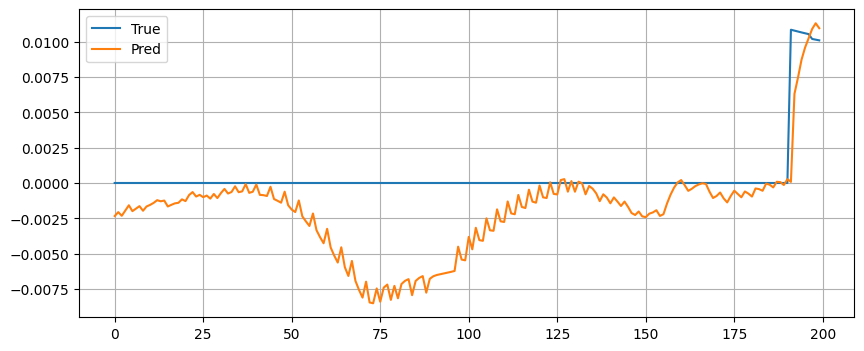

In [ ]:
y_pred = model.predict(X_val).flatten()

plt.figure(figsize=(10,4))
plt.plot(y_val[:200], label="True")
plt.plot(y_pred[:200], label="Pred")
plt.legend(); plt.grid(True)
plt.show()


In [ ]:
mu = np.mean(y_train)
sigma = np.std(y_train)

low  = mu - 3*sigma
high = mu + 3*sigma

y_pred_clipped = np.clip(y_pred, low, high)

print("clip low/high:", low, high)


clip low/high: -0.013542471544087472 0.019613072485505877


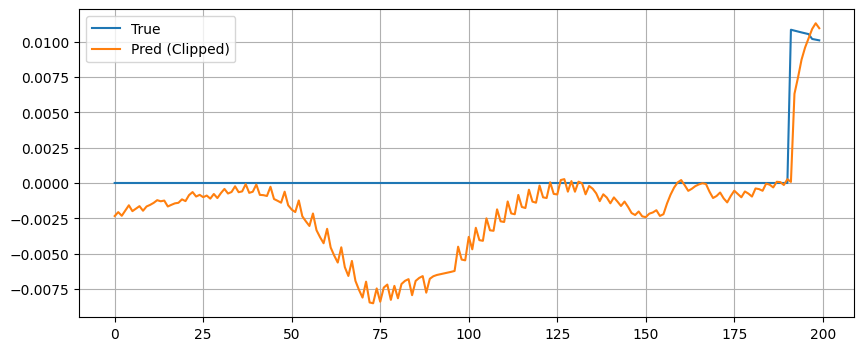

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_val[:200], label="True")
plt.plot(y_pred_clipped[:200], label="Pred (Clipped)")
plt.legend(); plt.grid(True)
plt.show()


In [ ]:
df_ml_B = df_ml.copy()


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()


df_ml_B[features] = scaler_X.fit_transform(df_ml_B[features].values)


df_ml_B["target_scaled"] = scaler_y.fit_transform(
    df_ml_B[[target]]
).flatten()


In [ ]:
df_ml_B["target_smooth"] = (
    df_ml_B["target_scaled"]
    .rolling(window=5, center=True, min_periods=1)
    .mean()
)

target_B = "target_smooth"


In [ ]:
window_B = 30
n_features = len(features)


In [ ]:
X_B, y_B = make_sequences(df_ml_B, features, target_B, window_B)

split = int(0.8 * len(X_B))
X_train_B, X_val_B = X_B[:split], X_B[split:]
y_train_B, y_val_B = y_B[:split], y_B[split:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

model_B = Sequential([
    LSTM(64, input_shape=(window_B, n_features)),
    Dense(1)
])

model_B.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse"
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history_B = model_B.fit(
    X_train_B, y_train_B,
    validation_data=(X_val_B, y_val_B),
    epochs=30,
    batch_size=32
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.4751 - val_loss: 0.0537
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0562 - val_loss: 0.0353
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0405 - val_loss: 0.0274
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0300 - val_loss: 0.0207
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0255 - val_loss: 0.0174
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0203 - val_loss: 0.0166
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0193 - val_loss: 0.0161
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0165 - val_loss: 0.0110
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0141 - val_loss: 0.0118
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0163 - val_loss: 0.0119
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0121 - val_loss: 0.0098
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0116 - val_l

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


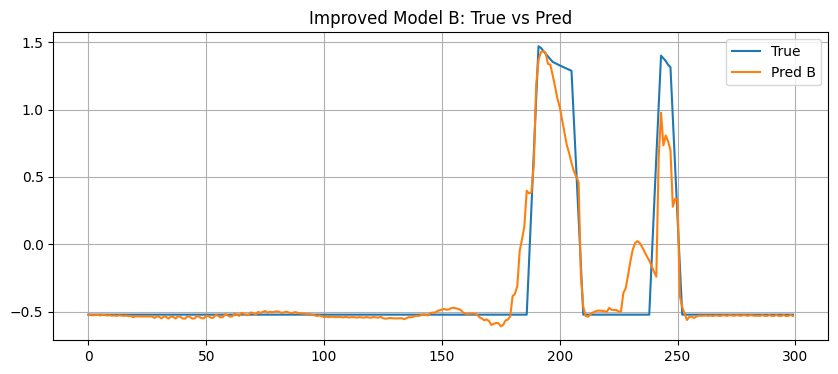

In [ ]:
y_pred_B = model_B.predict(X_val_B).flatten()

plt.figure(figsize=(10,4))
plt.plot(y_val_B[:300], label="True")
plt.plot(y_pred_B[:300], label="Pred B")
plt.legend()
plt.grid(True)
plt.title("Improved Model B: True vs Pred")
plt.show()


In [ ]:
mse_B = np.mean((y_val_B - y_pred_B)**2)
print("MSE_B:", mse_B)


MSE_B: 0.015285190465011289


In [ ]:
print("MSE_A:", mse_A)
print("MSE_B:", mse_B)


MSE_A: 6.250557729688631e-06
MSE_B: 0.015285190465011289


In [ ]:
# من training
mu = np.mean(y_train)
sigma = np.std(y_train)

LOW_LOAD  = mu - 0.5*sigma
HIGH_LOAD = mu + 0.5*sigma


In [ ]:
v_low_base  = 21.0
v_high_base = 23.0
P_on_base   = 150.0


In [ ]:
def adaptive_pg_params(pred_energy):
    v_low  = v_low_base
    v_high = v_high_base
    P_on   = P_on_base

    if pred_energy > HIGH_LOAD:
        # حمل عالي → glide أطول
        v_high -= 1.0
        P_on   -= 20.0

    elif pred_energy < LOW_LOAD:
        # حمل قليل → pull أقوى
        v_high += 0.5
        P_on   += 10.0

    # أمان
    v_high = np.clip(v_high, v_low + 1.0, 30.0)
    P_on   = np.clip(P_on, 60.0, 200.0)

    return v_low, v_high, P_on


In [ ]:
log_pred_energy = []
log_v_high = []
log_P_on = []

for i in range(window, len(df_ml)):

    seq = df_ml[features].iloc[i-window:i].values
    seq = seq.reshape(1, window, n_features)

    pred_energy = model.predict(seq, verbose=0)[0,0]

    v_low, v_high, P_on = adaptive_pg_params(pred_energy)

    log_pred_energy.append(pred_energy)
    log_v_high.append(v_high)
    log_P_on.append(P_on)


In [ ]:
print("len pred:", len(log_pred_energy))
print("len v_high:", len(log_v_high))
print("len P_on:", len(log_P_on))


len pred: 3657
len v_high: 3657
len P_on: 3657


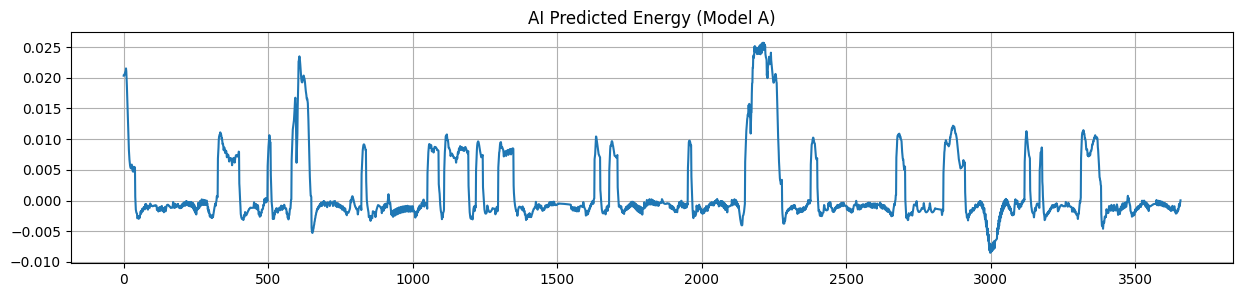

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))
plt.plot(log_pred_energy)
plt.title("AI Predicted Energy (Model A)")
plt.grid(True)
plt.show()


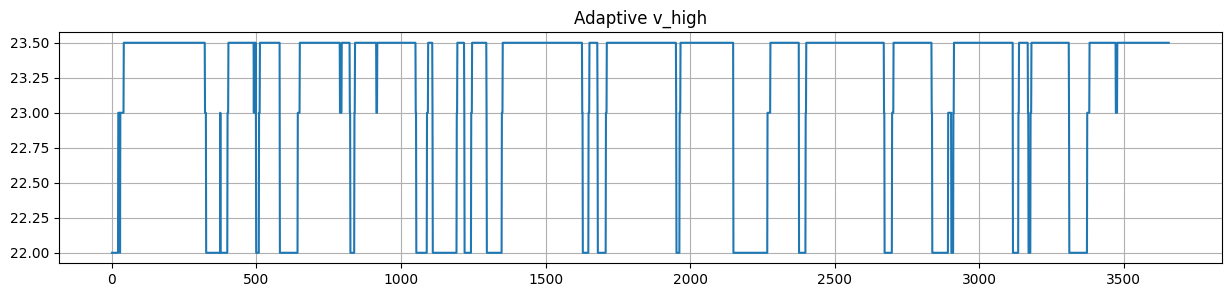

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(log_v_high)
plt.title("Adaptive v_high")
plt.grid(True)
plt.show()


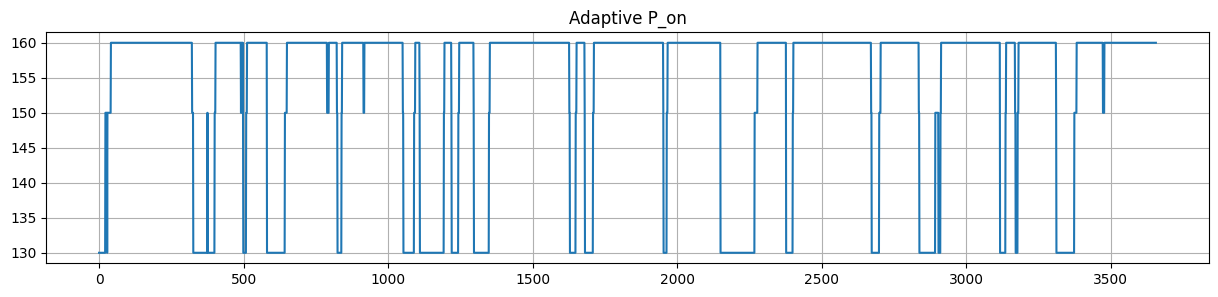

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(log_P_on)
plt.title("Adaptive P_on")
plt.grid(True)
plt.show()


In [ ]:
print(min(log_v_high), max(log_v_high))
print(min(log_P_on), max(log_P_on))


22.0 23.5
130.0 160.0


؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟؟

In [ ]:
def adaptive_pg_params_continuous(pred_energy):
    load_index = (pred_energy - LOW_LOAD) / (HIGH_LOAD - LOW_LOAD)
    load_index = np.clip(load_index, 0.0, 1.0)

    P_min, P_max = 130.0, 160.0
    v_high_min, v_high_max = 22.0, 23.5

    P_on = P_max - load_index * (P_max - P_min)
    v_high = v_high_max - load_index * (v_high_max - v_high_min)

    v_low = v_high - 2.0

    return v_low, v_high, P_on


In [ ]:
def adaptive_pg_params_direct(pred_energy):
    P_base = 150.0
    v_high_base = 23.0
    v_low_base = 21.0

    mu = np.mean(y_train)

    delta_load = pred_energy - mu

    Kp = 800
    Kv = 40

    delta_P = np.clip(-Kp * delta_load, -20, 20)
    delta_v = np.clip(-Kv * delta_load, -1.0, 1.0)

    P_on = P_base + delta_P
    v_high = v_high_base + delta_v
    v_low = v_high - 2.0

    return v_low, v_high, P_on


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

P_base = 150.0
v_high_base = 23.0

delta_P = np.array(log_P_on) - P_base
delta_v = np.array(log_v_high) - v_high_base

x = np.arange(len(delta_P))

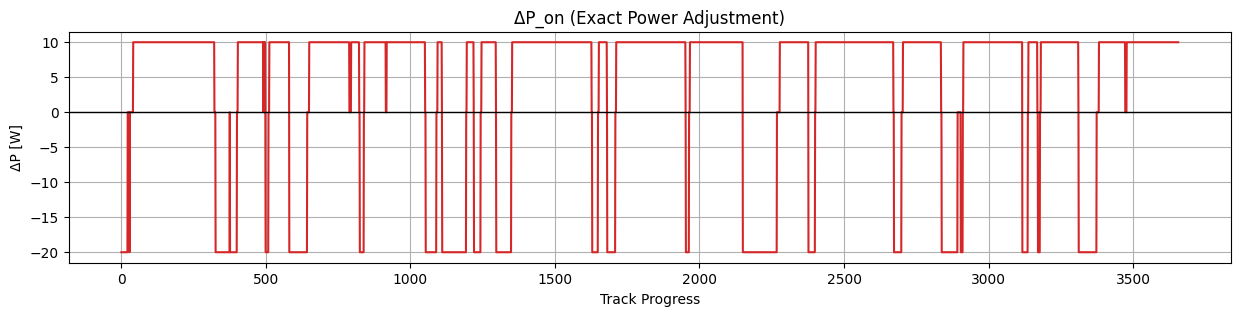

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(x, delta_P, color="tab:red")
plt.axhline(0, color="k", linewidth=1)
plt.title("ΔP_on (Exact Power Adjustment)")
plt.xlabel("Track Progress")
plt.ylabel("ΔP [W]")
plt.grid(True)
plt.show()


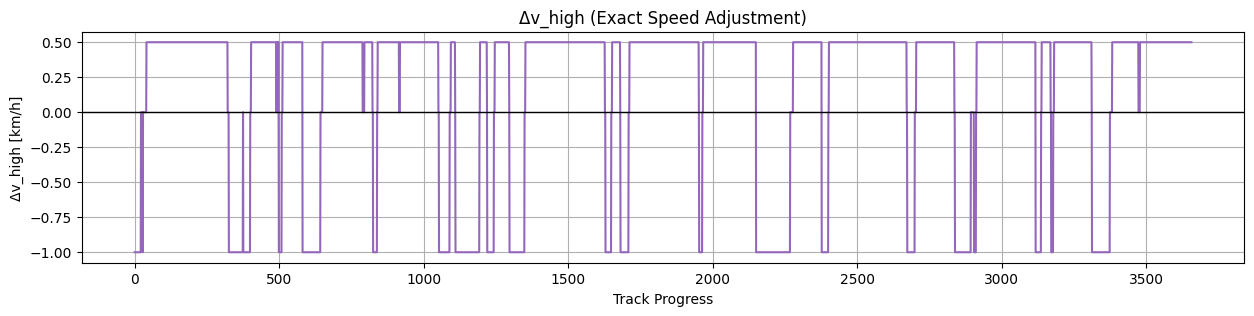

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(x, delta_v, color="tab:purple")
plt.axhline(0, color="k", linewidth=1)
plt.title("Δv_high (Exact Speed Adjustment)")
plt.xlabel("Track Progress")
plt.ylabel("Δv_high [km/h]")
plt.grid(True)
plt.show()


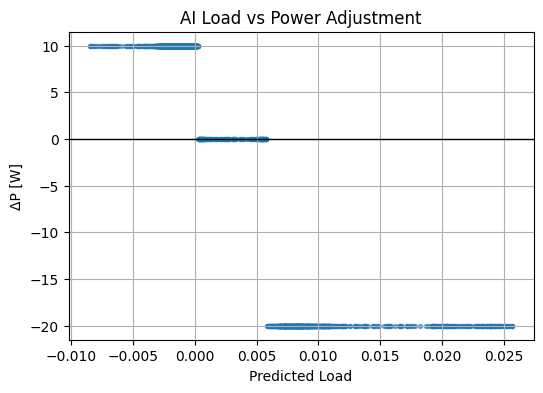

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(log_pred_energy, delta_P, s=8, alpha=0.6)
plt.axhline(0, color="k", linewidth=1)
plt.title("AI Load vs Power Adjustment")
plt.xlabel("Predicted Load")
plt.ylabel("ΔP [W]")
plt.grid(True)
plt.show()


In [ ]:
print("ΔP range [W]:", np.min(delta_P), "to", np.max(delta_P))
print("Δv range [km/h]:", np.min(delta_v), "to", np.max(delta_v))


ΔP range [W]: -20.0 to 10.0
Δv range [km/h]: -1.0 to 0.5


In [ ]:
++++++++++++++++++++++++++++++

In [ ]:
target_speed = "v_kmh"


In [ ]:
sim["v_kmh"]


,v_kmh
0,8.369900
1,9.194455
2,9.881297
3,10.476851
4,11.006462
...,...
3672,24.092974
3673,24.065310
3674,24.037648
3675,24.009987


In [ ]:
features_speed = [
    "slope",
    "curvature_smooth",
    "v_limit_kmh"
]


In [ ]:
df_speed = df.copy()
df_speed["v_kmh"] = sim["v_kmh"].values

df_speed = df_speed.dropna().reset_index(drop=True)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()


In [ ]:
window = 20
X, y = make_sequences(
    df_speed,
    features_speed,
    target_speed,
    window
)


In [ ]:
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler_X.fit_transform(X_reshaped).reshape(X.shape)

y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).flatten()


In [ ]:
split = int(0.8 * len(X_scaled))

X_train, X_val = X_scaled[:split], X_scaled[split:]
y_train, y_val = y_scaled[:split], y_scaled[split:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

model_speed = Sequential([
    LSTM(64, input_shape=(window, len(features_speed))),
    Dense(1)
])

model_speed.compile(
    optimizer=Adam(0.001),
    loss="mse"
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model_speed.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32
)


Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7494 - val_loss: 1.3645
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4689 - val_loss: 1.5120
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4583 - val_loss: 1.3456
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4227 - val_loss: 1.2435
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3721 - val_loss: 1.0648
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3817 - val_loss: 1.1693
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3717 - val_loss: 1.3358
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3565 - val_loss: 1.2665
Epoch 9/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3685 - val_loss: 1.4509
Epoch 10/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3422 - val_loss: 1.2253
Epoch 11/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3660 - val_loss: 1.3782
Epoch 12/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3367 - val_lo

In [ ]:
y_pred_scaled = model_speed.predict(X_val).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_true = scaler_y.inverse_transform(y_val.reshape(-1,1)).flatten()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


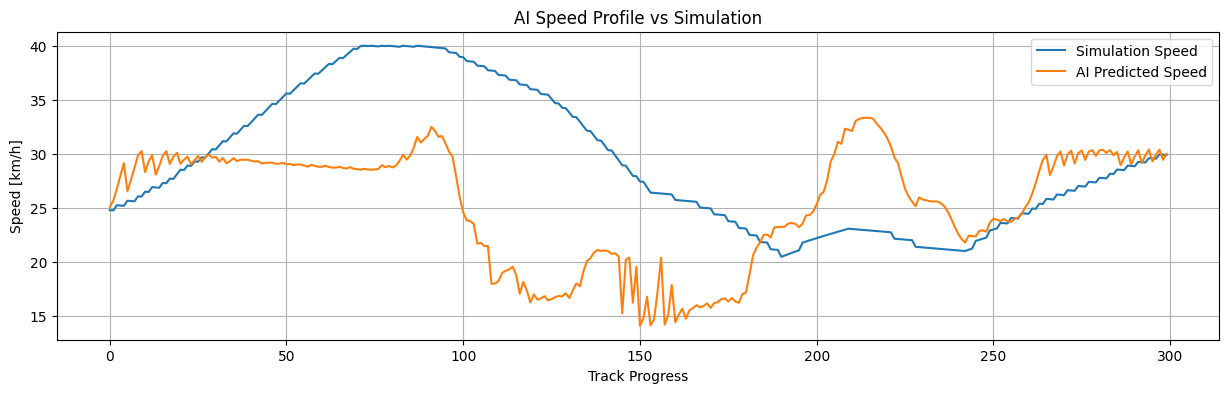

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(y_true[:300], label="Simulation Speed")
plt.plot(y_pred[:300], label="AI Predicted Speed")
plt.legend()
plt.xlabel("Track Progress")
plt.ylabel("Speed [km/h]")
plt.grid(True)
plt.title("AI Speed Profile vs Simulation")
plt.show()


In [ ]:
features_speed_state = [
    "slope",
    "curvature_smooth",
    "v_limit_kmh",
    "v_prev",          # v(t-1)
    "motor_on_prev"    # motor state at (t-1)
]
target_speed = "v_kmh"


In [ ]:
df_state = df.copy()
df_state["v_kmh"] = sim["v_kmh"].values
df_state["motor_on"] = sim["motor_on"].values

df_state["v_prev"] = df_state["v_kmh"].shift(1)
df_state["motor_on_prev"] = df_state["motor_on"].shift(1)

df_state = df_state.dropna().reset_index(drop=True)


In [ ]:
window = 20

X, y = make_sequences(
    df_state,
    features_speed_state,
    target_speed,
    window
)

from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

Xr = X.reshape(-1, X.shape[-1])
Xs = scaler_X.fit_transform(Xr).reshape(X.shape)
ys = scaler_y.fit_transform(y.reshape(-1,1)).flatten()


In [ ]:
split = int(0.8 * len(Xs))
X_train, X_val = Xs[:split], Xs[split:]
y_train, y_val = ys[:split], ys[split:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

model_state = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, X.shape[-1])),
    LSTM(32),
    Dense(1)
])

model_state.compile(
    optimizer=Adam(0.0005),
    loss="mse"
)

history = model_state.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2102 - val_loss: 0.0400
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0062 - val_loss: 0.0225
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - val_loss: 0.0160
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024 - val_loss: 0.0139
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - val_loss: 0.0106
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019 - val_loss: 0.0140
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019 - val_loss: 0.0101
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018 - val_loss: 0.0103
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018 - val_loss: 0.0099
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018 - val_loss: 0.0096
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0074
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017 - val_loss: 0.00

In [ ]:
y_pred_s = model_state.predict(X_val).flatten()

y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
y_true = scaler_y.inverse_transform(y_val.reshape(-1,1)).flatten()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
# احترام حدود السرعة
vlim_val = df_state["v_limit_kmh"].values[window+split:]
y_pred = np.minimum(y_pred, vlim_val[:len(y_pred)])

# Smoothing خفيف (اختياري)
y_pred = pd.Series(y_pred).rolling(5, center=True, min_periods=1).mean().values


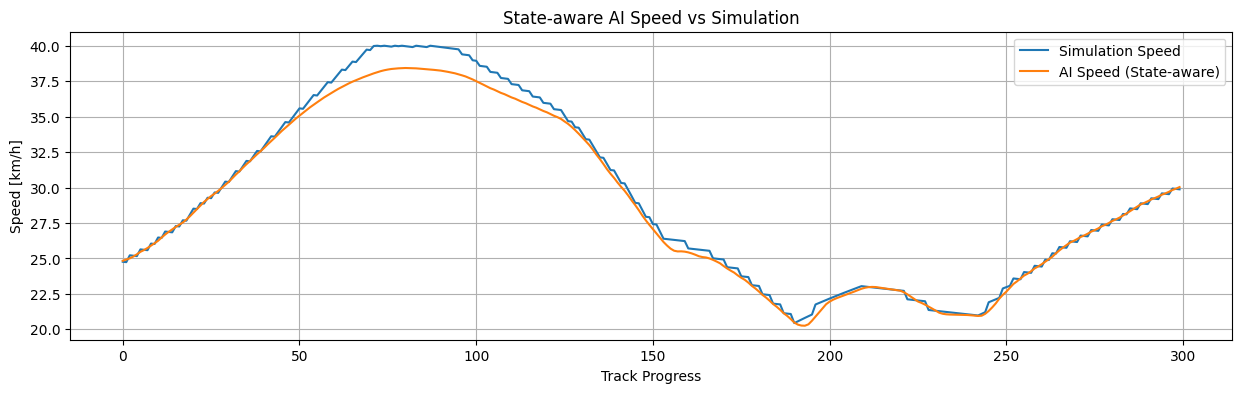

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(y_true[:300], label="Simulation Speed")
plt.plot(y_pred[:300], label="AI Speed (State-aware)")
plt.legend()
plt.xlabel("Track Progress")
plt.ylabel("Speed [km/h]")
plt.grid(True)
plt.title("State-aware AI Speed vs Simulation")
plt.show()
